# Dissertation CAT 1

## Predicting Financial Exclusion in Kenya Using Machine Learning

### Admission Number: 134022

# Introduction

### Background
Financial exclusion remains a critical policy challenge in Kenya.
This project applies machine learning techniques to predict individuals
at risk of financial exclusion using the FinAccess 2024 Household Survey.

The FinAccess Household Survey is a comprehensive dataset that provides insights into the financial inclusion status of individuals across Kenya. It captures a wide range of information on access to, usage of, and perceptions towards various financial services, including banking, mobile money, insurance, savings, credit, and investment products. The survey aims to understand financial behavior, identify barriers to access to financial services and assess the impact of different financial services on households. It also contains demographic, geographic and socioeconomic data that enables a holistic analysis of financial inclusion across counties and different population segments.

### Research Problem

Despite substantial progress in expanding financial services in Kenya, approximately 10% of adults remain completely excluded from both formal and informal financial systems. Current policies and interventions are often generalized, lacking the granularity to target populations most at risk. The main research problem addressed in this study is:

How can machine learning models be used to predict financial exclusion among Kenyan adults using socio-demographic, economic, and technology-access indicators, and how can these predictions support targeted financial inclusion policies?

This study aims to assess the relative importance of socio-economic, demographic, and technological variables in explaining financial exclusion.



# Data Understanding

#### Data Description

The dataset used in this study is the 2024 FinAccess Household Survey dataset. It contains over 3,800 variables covering demographic, geographic, and financial access information. The dataset was obtained from the Kenya National Bureau of Statistics (KNBS). It was collected between January and March 2024 through household interviews by trained enumerators. The survey covered all counties in Kenya, with respondents selected through a stratified random sampling method to ensure representation of both urban and rural populations in Kenya.


| Variable Name              | Description                                                                        |
| -------------------------- | ---------------------------------------------------------------------------------- |
| `age`                      | Age of the respondent in years                                                     |
| `gender`                   | Gender of the respondent (Male/Female)                                             |
| `education_level`          | Highest level of education attained    |
| `marital_status`           | Marital status of respondent                |
| `household_size`           | Number of individuals living in the household                                      |
| `insurance_usage`        | Use of inaurance services |
| `income_source`            | Primary source of income       |
| `location_type`            | Type of residence (Urban, Rural)                                                   |
| `county`                   | County of residence                                                          |
| `id_ownership`              | Ownership of national identification                                      |
| `mobile_phone_ownership`             | Ownership of a mobile phone                                              |
| `internet_access`          | Access to the internet                                                  |
| `disability_status`          | Disability status of respondent                                                  |
| `bank_usage` | Use of any banking services           |
| `mobile_money_usage` | Use of any mobile money services           |
| `sacco_usage` | Use of any sacco services           |
| `informal_savings_usage` | Use of any informal savings such as chamas         |
| `financial_exclusion`      | Target variable: 1 if no financial service is used, 0 otherwise                    |


In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC

# Boosting
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Explainability
import shap

from sklearn.utils.class_weight import compute_class_weight
import joblib


In [3]:
# Load dataset
df = pd.read_csv("Data/finaccess_2024_dataset.csv")

#### Data Preview

In [4]:
# Display row and columns
print("Data Shape:", df.shape)

Data Shape: (20871, 17)


In [5]:
df.head()

,county,location_type,gender,age,household_size,education_level,income_source,internet_access,marital_status,id_ownership,mobile_phone_ownership,bank_usage,mobile_money_usage,sacco_usage,informal_savings_usage,insurance_usage,disability_status
0,Garissa,Urban,Male,29,5,Completed technical training after secondary s...,support from family / friends / spouse,0.0,Married/Living with partner,"Has ID (National Identity Card (ID),Passport,A...",Yes,Currently use,Currently use,Never used,Never used,Never used,Without Disability
1,Garissa,Urban,Male,60,11,"""None """,None of these,0.0,Married/Living with partner,"Has ID (National Identity Card (ID),Passport,A...",Yes,Never used,Currently use,Never used,Never used,Never used,Without Disability
2,Busia,Urban,Female,35,2,"""Primary completed""",Casual worker/Seasonal Worker,0.0,Divorced/separated,"Has ID (National Identity Card (ID),Passport,A...",Yes,Currently use,Currently use,Never used,Currently use,Never used,Without Disability
3,Kiambu,Urban,Male,24,1,"""Some secondary""",Casual worker/Seasonal Worker,0.0,Single/Never Married,"Has ID (National Identity Card (ID),Passport,A...",Yes,Used to use,Currently use,Never used,Never used,Never used,Without Disability
4,Murang'a,Urban,Female,20,1,Some technical training after secondary school,support from family / friends / spouse,1.0,Single/Never Married,"Has ID (National Identity Card (ID),Passport,A...",Yes,Currently use,Currently use,Never used,Never used,Never used,Without Disability


In [6]:
# Display data overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20871 entries, 0 to 20870
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   county                  20871 non-null  object 
 1   location_type           20871 non-null  object 
 2   gender                  20871 non-null  object 
 3   age                     20871 non-null  int64  
 4   household_size          20871 non-null  int64  
 5   education_level         20871 non-null  object 
 6   income_source           20871 non-null  object 
 7   internet_access         20772 non-null  float64
 8   marital_status          20871 non-null  object 
 9   id_ownership            20871 non-null  object 
 10  mobile_phone_ownership  20871 non-null  object 
 11  bank_usage              20864 non-null  object 
 12  mobile_money_usage      20865 non-null  object 
 13  sacco_usage             20861 non-null  object 
 14  informal_savings_usage  20861 non-null

In [7]:
# Display Summary statistics of the dataset
display(df.describe(include='all').T.fillna(''))

C:\Users\USER\AppData\Local\Temp\ipykernel_14268\2177296213.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  display(df.describe(include='all').T.fillna(''))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
county,20871.0,47,Meru,637,,,,,,,
location_type,20871.0,2,Rural,13549,,,,,,,
gender,20871.0,2,Male,14271,,,,,,,
age,20871.0,,,,39.271429,17.210021,16.0,26.0,35.0,50.0,105.0
household_size,20871.0,,,,4.215946,2.512658,1.0,2.0,4.0,6.0,20.0
education_level,20871.0,13,"""Secondary completed """,4113,,,,,,,
income_source,20871.0,13,Casual worker/Seasonal Worker,4902,,,,,,,
internet_access,20772.0,,,,0.300741,0.458591,0.0,0.0,0.0,1.0,1.0
marital_status,20871.0,5,Married/Living with partner,11432,,,,,,,
id_ownership,20871.0,2,"Has ID (National Identity Card (ID),Passport,A...",18722,,,,,,,


#### Data Cleaning

In [8]:
#check for duplicates
print("Duplicate rows: ", df.duplicated().sum())

Duplicate rows:  86


In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)
print("Duplicate rows after removal: ", df.duplicated().sum())

Duplicate rows after removal:  0


In [10]:
# check for missing value
print("Missing values per column:\n ", df.isnull().sum())

Missing values per column:
  county                     0
location_type              0
gender                     0
age                        0
household_size             0
education_level            0
income_source              0
internet_access           99
marital_status             0
id_ownership               0
mobile_phone_ownership     0
bank_usage                 7
mobile_money_usage         6
sacco_usage               10
informal_savings_usage    10
insurance_usage            0
disability_status          0
dtype: int64


In [11]:
# Handle missing values

# Internet access (0/1) - treat 0 as No, 1 as Yes
# Fill missing values with mode
df['internet_access'] = df['internet_access'].fillna(df['internet_access'].mode()[0])

cat_cols = ['internet_access', 'bank_usage', 'mobile_money_usage', 'sacco_usage', 'informal_savings_usage']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
# Verify missing values
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 county                    0
location_type             0
gender                    0
age                       0
household_size            0
education_level           0
income_source             0
internet_access           0
marital_status            0
id_ownership              0
mobile_phone_ownership    0
bank_usage                0
mobile_money_usage        0
sacco_usage               0
informal_savings_usage    0
insurance_usage           0
disability_status         0
dtype: int64


##### Cleaning the Education Coumn

In [13]:
# Convert to string
df['education_level'] = df['education_level'].astype(str)

# Remove quotation marks
df['education_level'] = df['education_level'].str.replace('"', '', regex=False)

# Strip leading/trailing spaces
df['education_level'] = df['education_level'].str.strip()


In [14]:
df['education_level'] = df['education_level'].replace({'95': 'Unknown'})

In [15]:
education_map = {
    # No education
    'None': 'No formal education',

    # Primary
    'Some primary': 'Primary education',
    'Primary completed': 'Primary education',

    # Secondary
    'Some secondary': 'Secondary education',
    'Secondary completed': 'Secondary education',

    # Tertiary
    'Completed technical training after secondary school': 'Tertiary education',
    'Some technical training after secondary school': 'Tertiary education',
    'Some university': 'Tertiary education',
    'University completed': 'Tertiary education',

    # Unknown
    'Refused to Answer (DO NOT READ OUT)': 'Unknown',
    "Don't know (DO NOT READ OUT)": 'Unknown',
    'Other (Specify)': 'Unknown',
    'Other': 'Unknown'
}

df['education_level_clean'] = df['education_level'].map(education_map)

print("Still unmapped:")
print(df.loc[df['education_level_clean'].isnull(), 'education_level'].unique())

df['education_level'] = df['education_level_clean']
df.drop(columns=['education_level_clean'], inplace=True)


Still unmapped:
['Unknown']


In [16]:
#Verification
print(df['education_level'].value_counts(normalize=True) * 100)

education_level
Primary education      36.924409
Secondary education    32.747919
Tertiary education     15.618534
No formal education    14.675456
Unknown                 0.033681
Name: proportion, dtype: float64


In [17]:
# Categorical columns with special values
# education_level → combine rare categories
rare_edu = ['95', "Don't Know", "Refused to Answer", "Other (Specify)"]
df['education_level'] = df['education_level'].replace(rare_edu, 'Other')
# marital_status → combine "Don't Know/refused" as 'Unknown'
df['marital_status'] = df['marital_status'].replace(["Don't Know/refused"], 'Unknown')

#### Target Variable Construction

In [18]:
service_columns = [
    "bank_usage",
    "mobile_money_usage",
    "sacco_usage",
    "informal_savings_usage",
    "insurance_usage"
]

service_map = {'Currently use': 1, 'Used to use': 0, 'Never used': 0}
for col in service_columns:
    df[col] = df[col].map(service_map)


# Construct financial exclusion target
# 1 → excluded (no service currently used)
# 0 → included (uses at least one service)
df["financial_exclusion_status"] = (df[service_columns].sum(axis=1) == 0).astype(int)

# Check target distribution
print("Target value counts:\n", df["financial_exclusion_status"].value_counts())

# Calculate exclusion rate %
exclusion_rate = df["financial_exclusion_status"].mean() * 100
print(f"Financial exclusion rate: {exclusion_rate:.2f}%")

Target value counts:
 financial_exclusion_status
0    17224
1     3561
Name: count, dtype: int64
Financial exclusion rate: 17.13%


# Data Preparation

In [19]:
# Separate features and target
X = df.drop("financial_exclusion_status", axis=1)
y = df["financial_exclusion_status"]

In [20]:
# Column types
numeric_features = ['age', 'household_size']
categorical_features = ['education_level', 'county', 'location_type', 'marital_status', 'income_source', 'disability_status']
binary_features = ['id_ownership', 'mobile_phone_ownership', 'internet_access']

# Binary encoding for id_ownership, mobile_phone_ownership
X['id_ownership'] = X['id_ownership'].apply(lambda x: 1 if 'Has ID' in x else 0)
X['mobile_phone_ownership'] = X['mobile_phone_ownership'].apply(lambda x: 1 if x=='Yes' else 0)
# internet_access is already numeric (0/1), no change needed

# Preprocessing pipeline
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Include binary columns in numeric transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features + binary_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [21]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# Original training set shape and distribution remain relevant
print(f"Original training set shape: {X_train.shape}")
print(f"Original target distribution:\n{pd.Series(y_train).value_counts()}")

Original training set shape: (16628, 17)
Original target distribution:
financial_exclusion_status
0    13779
1     2849
Name: count, dtype: int64


In [23]:
smote = SMOTE(random_state=42)

# Exploratory Data Analysis (EDA)

In [24]:
# Set plot style
sns.set(style="whitegrid")

#### Descriptive Analysis

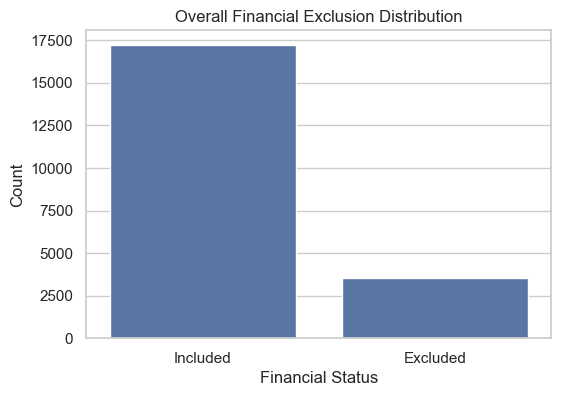

In [25]:
# Mapping for descriptive labels
status_labels = {0: 'Included', 1: 'Excluded'}

# Overall financial exclusion distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['financial_exclusion_status'].map(status_labels))
plt.title("Overall Financial Exclusion Distribution")
plt.xlabel("Financial Status")
plt.ylabel("Count")
plt.show()


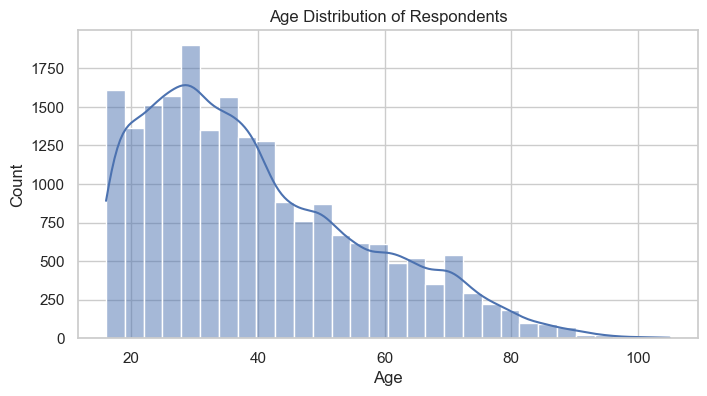

In [26]:
# Age distribution
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution of Respondents")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

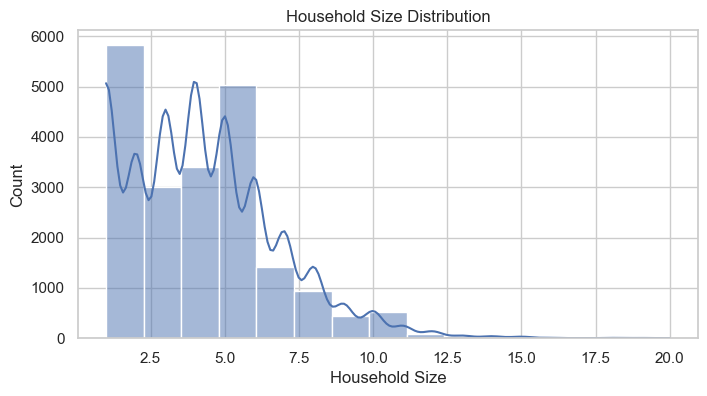

In [27]:
# Household size distribution
plt.figure(figsize=(8,4))
sns.histplot(df['household_size'], bins=15, kde=True)
plt.title("Household Size Distribution")
plt.xlabel("Household Size")
plt.ylabel("Count")
plt.show()

In [28]:
# Gender distribution
gender_counts = df['gender'].value_counts(normalize=True) * 100
print("Gender distribution (%):\n", gender_counts)

Gender distribution (%):
 gender
Male      68.328121
Female    31.671879
Name: proportion, dtype: float64


In [29]:
# Education level distribution
edu_counts = df['education_level'].value_counts(normalize=True) * 100
print("\nEducation Level distribution (%):\n", edu_counts)


Education Level distribution (%):
 education_level
Primary education      36.924409
Secondary education    32.747919
Tertiary education     15.618534
No formal education    14.675456
Unknown                 0.033681
Name: proportion, dtype: float64


##### Demographic Distribution Interpretation

The gender and education level distributions reveal important demographic characteristics of the FinAccess survey respondents:

**Gender Distribution:**
- The analysis shows a significant gender disparity with males compromising over 68% of respondents.
- This imbalanced gender representation must be addressed to avoid bias.

**Education Level Distribution:**
- The percentages across education categories indicate the educational attainment levels of respondents.
- The education distribution shows that 70% of respondents have attained at most secondary education suggesting that financial literacy and formal employment which are both correlated with higher education, may be key barriers to inclusion.

#### Diagnostic Analysis

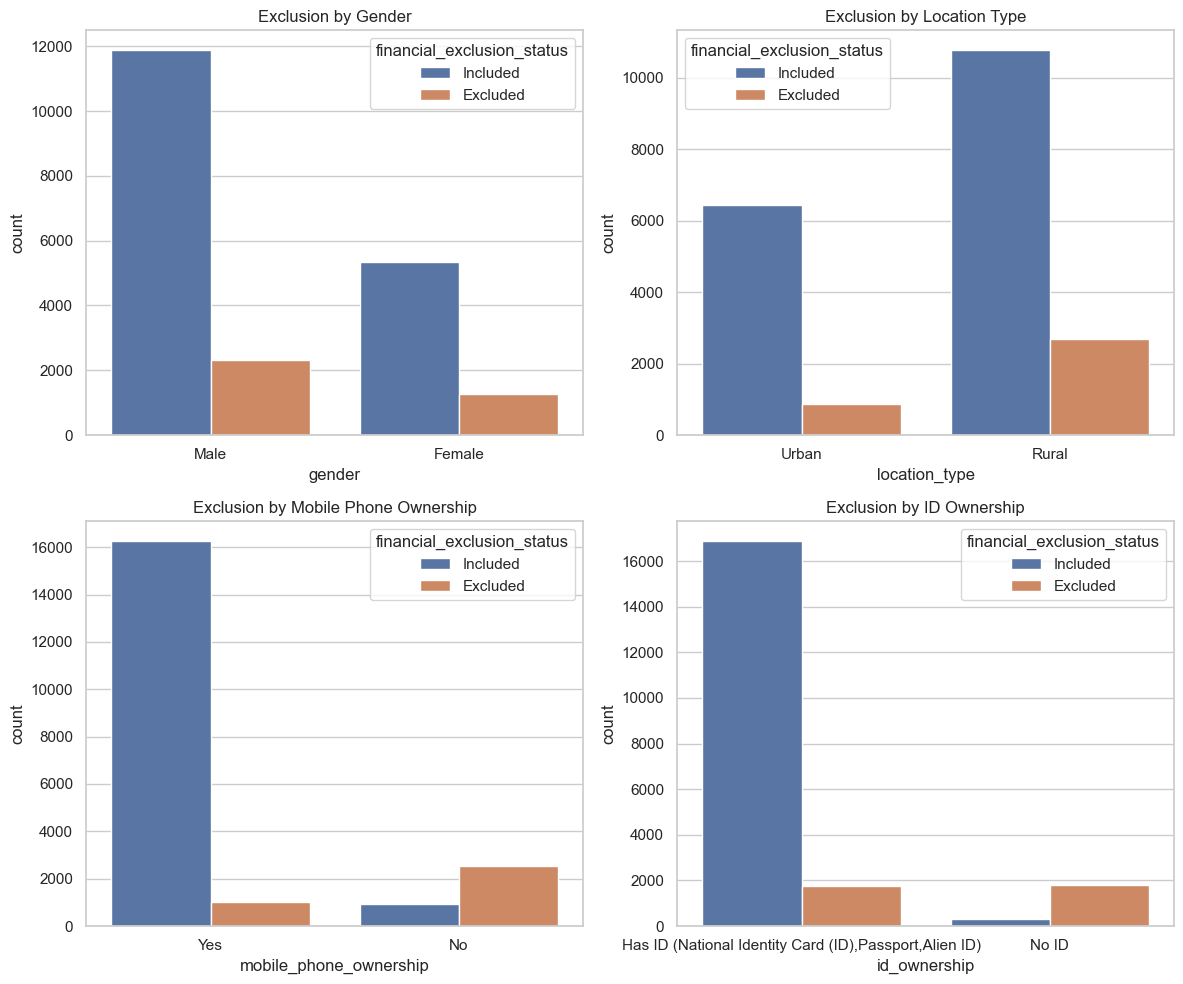

In [30]:
# Mapping for the legend
status_labels = {0: 'Included', 1: 'Excluded'}

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

# Exclusion by gender
sns.countplot(x='gender', hue=df['financial_exclusion_status'].map(status_labels), data=df, ax=axes[0])
axes[0].set_title("Exclusion by Gender")

# Exclusion by location_type
sns.countplot(x='location_type', hue=df['financial_exclusion_status'].map(status_labels), data=df, ax=axes[1])
axes[1].set_title("Exclusion by Location Type")

# Exclusion by mobile phone ownership
sns.countplot(x='mobile_phone_ownership', hue=df['financial_exclusion_status'].map(status_labels), data=df, ax=axes[2])
axes[2].set_title("Exclusion by Mobile Phone Ownership")

# Exclusion by ID ownership
sns.countplot(x='id_ownership', hue=df['financial_exclusion_status'].map(status_labels), data=df, ax=axes[3])
axes[3].set_title("Exclusion by ID Ownership")

plt.tight_layout()
plt.show()


##### Interpretation of Diagnostic Bivariate Analysis

The four diagnostic visualizations above reveal critical associations between demographic/structural variables and financial exclusion status:

**Key Observations:**
1. **Mobile Phone Ownership** - Mobile phone access is a critical enabler of digital financial services (M-Pesa, mobile banking). Those without mobile phones face significant barriers to financial inclusion.

2. **ID Ownership** - Lck of a national ID is a strong predictor of exclusion. National ID is a mandatory Know-Your-Cusyomer (KYC) requirement for formal financial account opening.

3. **Location Type Impact** - Rural  respondents have a higher proportion of exclusion compared to urban reposndents due to limited banking infrastructure and digital connectivity.

4. **Gender Exclusion Patterns** - Differences in exclusion rates between gender groups indicate potential gender-based socioeconomic disparities in financial access. However this is less pronounced than for ID or mobile ownership.

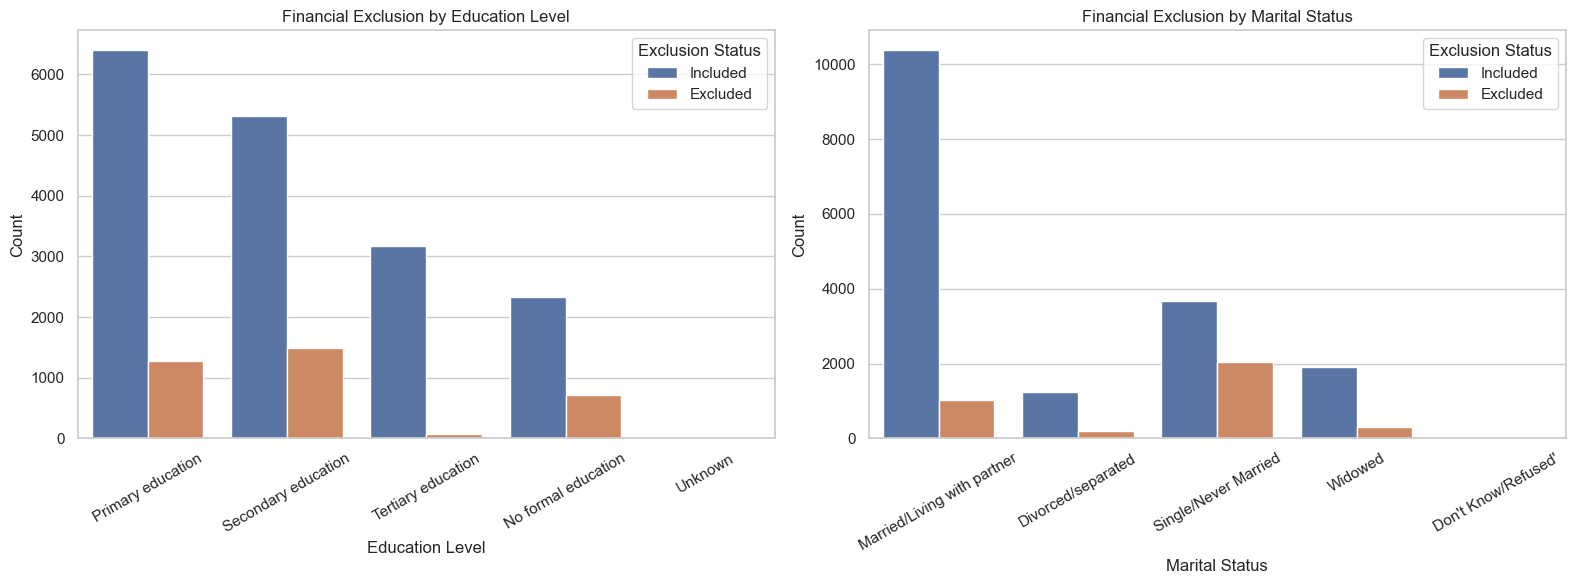

In [31]:
# Mapping for the legend
status_labels = {0: 'Included', 1: 'Excluded'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Exclusion by education_level
sns.countplot(x='education_level', hue=df['financial_exclusion_status'].map(status_labels), data=df, order=df['education_level'].value_counts().index, ax=axes[0])
axes[0].set_title("Financial Exclusion by Education Level")
axes[0].set_xlabel("Education Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title="Exclusion Status", labels=["Included", "Excluded"])

# Exclusion by marital_status
sns.countplot(x='marital_status', hue=df['financial_exclusion_status'].map(status_labels), data=df, ax=axes[1])
axes[1].set_title("Financial Exclusion by Marital Status")
axes[1].set_xlabel("Marital Status")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title="Exclusion Status", labels=["Included", "Excluded"])

plt.tight_layout()
plt.show()


##### Sociodemographic Factors in Financial Exclusion

The bivariate analysis reveals how education and marital status intersect with financial inclusion:

**Education Level Analysis:**
- Higher educational attainment correlates with formal financial service usage and lower exclusion rates.
- Individuals with "No formal education" have the highest exclusion rates, while those with "Tertiary education" have the lowest.
- This supports that financial literacy and access to formal employment are critical enablers.

**Marital Status Analysis:**
- Marital status can be a metric for household stability, dual income potential, and social safety nets.
- Married individuals show a lower rate of exclusion. This coul be due to better access to credit through joint applications and shared collateral.
- Single/divorced status may indicate vulnerability subgroups requiring targeted inclusion strategies.

**Contextual Geographic Insight:**
- The bar chart of the top 15 counties by exclusion rate identifies specific geographic hotspots.
- Counties like Garissa, Mandera, and Turkana consistently show exclusion rates above 40%, pointing to a need for regionally targeted policies.
- These areas often face unique challenges such as conflict, drought, and underdeveloped financial infrastructure.

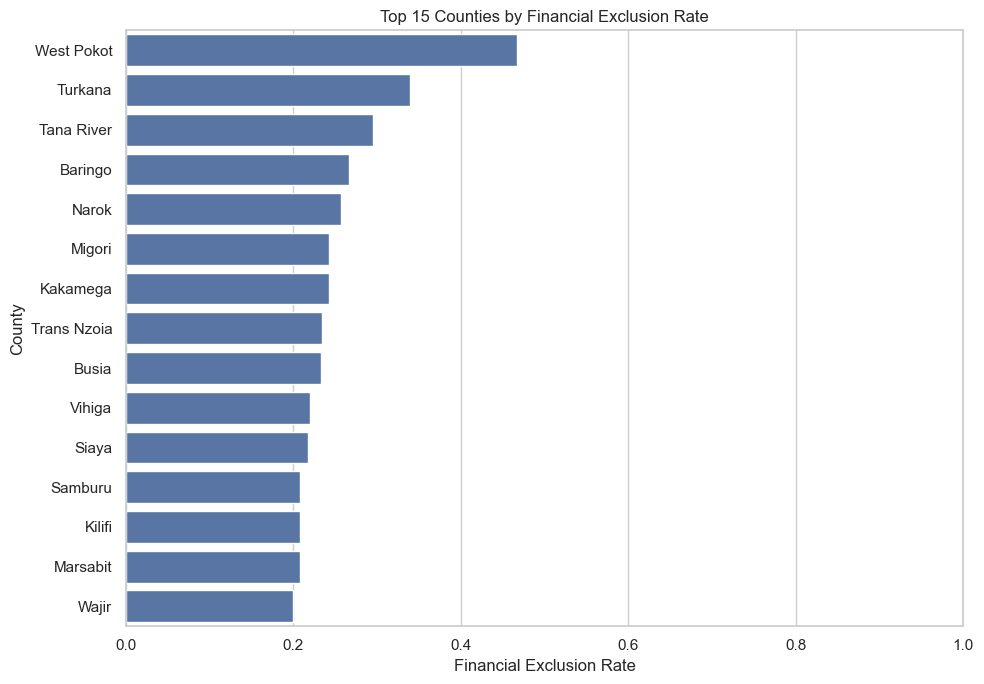

In [32]:
plt.figure(figsize=(10, 7))

top_counties = (
    df.groupby('county')['financial_exclusion_status']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

sns.barplot(
    x=top_counties.values,
    y=top_counties.index
)

plt.title("Top 15 Counties by Financial Exclusion Rate")
plt.xlabel("Financial Exclusion Rate")
plt.ylabel("County")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()


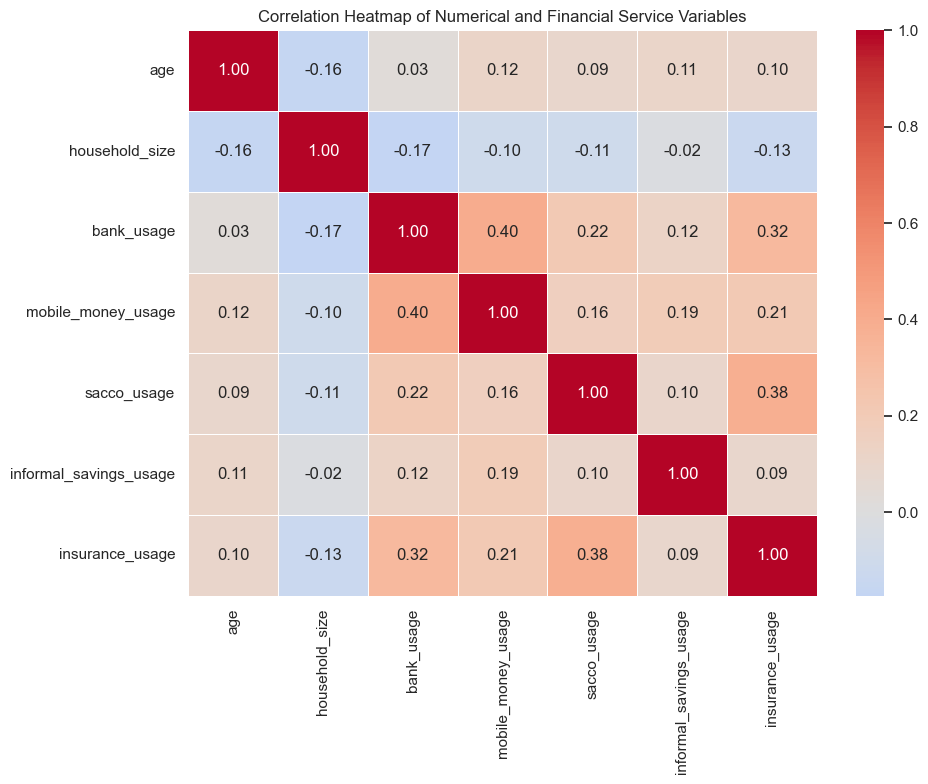

In [33]:
#Correlation Heatmap
plt.figure(figsize=(10, 8))

# Compute correlation matrix
corr_matrix = df[numeric_features + service_columns].corr()

# Plot heatmap with annotations
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5, annot=True,  fmt=".2f")

plt.title("Correlation Heatmap of Numerical and Financial Service Variables")
plt.tight_layout()
plt.show()



##### Correlation Analysis Interpretation

The correlation heatmap reveals multivariate relationships between demographic, service usage, and financial exclusion indicators:

**Key Correlation Insights:**
- **Strong Positive Correlations with Exclusion:** Features such as `bank_usage` and `insurance_usage` correlate positively with financial exclusion status indicating risk factors. This suggests that individuals who use one formal service are highly likely to use others.
- **Strong Negative Correlations with Exclusion:** `mobile_money_usage` has the strongest negative correlation with the `financial_exclusion_status`. This confirms that mobile money is the primary driver of financial inclusion in Kenya
- **Multi-collinearity Detection:** The heatmap is valuable for detecting redundant predictors. In this case, the features are sufficiently independent.

**Service Usage Patterns:**
- Correlations between different financial services (savings, credit, insurance, remittances) reveal service ecosystem interactions and customer behavior clustering.
- Strong positive correlations between services suggest complementarity; users who access one service often access others.
- Weak or negative correlations may indicate service gaps or unmet demand in specific segments.

# Machine Learning Modeling

This section details the development and comparative evaluation of four supervised learning models to predict financial exclusion **Recall** is prioritized as the primary performance metric, as the societal cost of failing to identify an excluded individual (a false negative) is far greater than the cost of a false positive (targeting an already included individual).

Four algorithms were implemented:
1.  **Logistic Regression:** Selected for its high interpretability, providing a clear baseline comparison.
2.  **Random Forest:** Selected for its ability to capture non-linear relationships and complex interactions between variables.
3.  **XGBoost:** Selected for its high performance on structured tabular data by iteratively correcting the errors of previous models.
4.  **Support Vector Machine (SVM):** Selected for its classification by finding the optimal hyperplane separating classes, effective in high-dimensional spaces.

There is a significant class imbalance (17% excluded vs. 83% included) which is addressed. To prevent the models from simply predicting the majority class, **SMOTE (Synthetic Minority Over-sampling Technique)** was applied within a pipeline. SMOTE generates synthetic samples for the minority class, creating a balanced training set.


In [34]:
# Logistic Regression Model
log_reg = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier", LogisticRegression(
        max_iter=1000,
        solver='lbfgs'
    ))
])

log_reg.fit(X_train, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [35]:
# Random Forest Model
rf_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [36]:
# XGBoost Model
xgb_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier", XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

print("XGBoost training complete.")

XGBoost training complete.


In [37]:
# SVM Model
svm_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier", SVC(
        probability=True,
        kernel='rbf'
    ))
])

svm_model.fit(X_train, y_train)

print("SVM training complete.")

SVM training complete.


In [38]:
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('svm', svm_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

print("Stacking Classifier training complete.")

Stacking Classifier training complete.


# Model Performance Evaluation

Model performance is evaluated using multiple metrics:
- Precision
- Recall
- F1-score
- ROC-AUC

Recall is emphasized because failing to identify financially excluded individuals
(false negatives) has higher policy and social costs than false positives.


In [39]:
def compare_models(models, X_test, y_test):
    results = []

    for name, model in models.items():
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
        results.append((name, auc))

    results_df = pd.DataFrame(results, columns=["Model", "ROC-AUC"])
    return results_df.sort_values(by="ROC-AUC", ascending=False)

In [40]:
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "SVM": svm_model,
    "Stacking Ensemble": stack_model
}

results_df = compare_models(models, X_test, y_test)
print(results_df)

                 Model   ROC-AUC
0  Logistic Regression  0.939465
4    Stacking Ensemble  0.939304
2              XGBoost  0.938234
3                  SVM  0.934571
1        Random Forest  0.932576


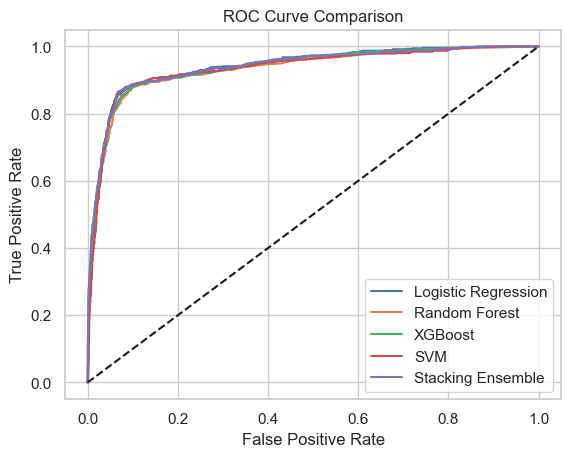

In [41]:
plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

##### **Model Performance Comparison**

The table and ROC curve above compare the performance of all four models.

**Analysis of Results:**

The comparison shows that all models perform highly, with ROC-AUC scores exceeding 0.93. This indicates that the chosen features are highly predictive of financial exclusion.

- **Logistic Regression** achives the highest ROC-AUC of o.9393, suggesting a strong underlying linear relationship between the log-odds of the features and the target variable.
- **XGBoost** achieves ROC-AUC of 0.9379, demonstrating its strength for this type of classification problem.
- **SVM** achives ROC-AUC of 0.9346 indicating that it performs very competitively but requires more computational resources for training and tuning.
- **Random Forest** shows a slightly lower ROC-AUC of 0.9302. This might indicate that while it captures interactions well, the dominant signals are linear and better captured by Logistic Regression or XGBoost.



#### Feature Importance for Random Forest

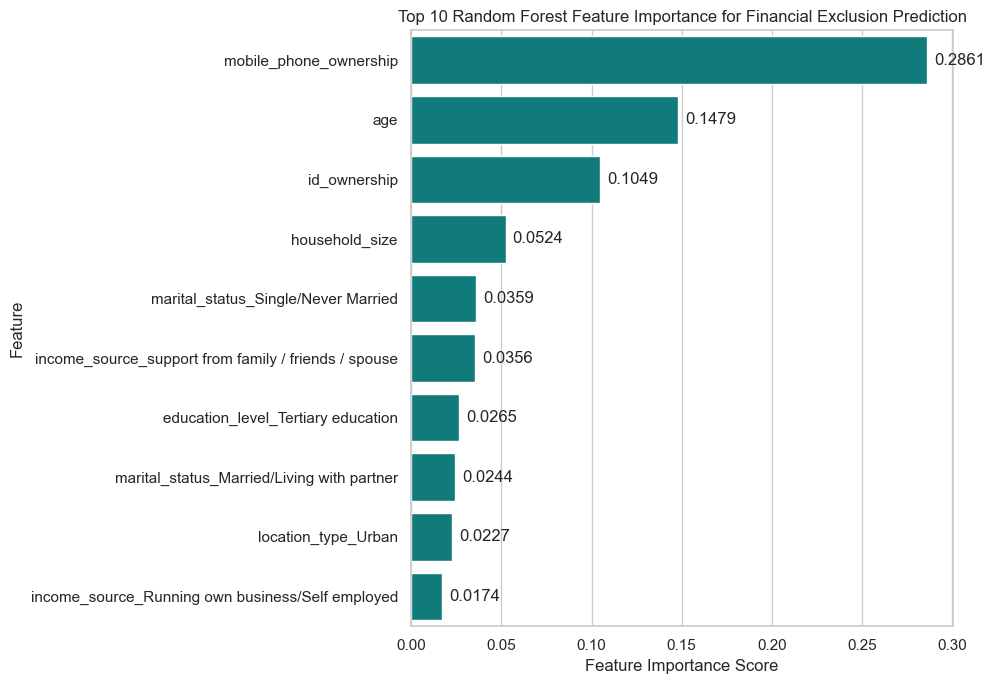

In [42]:
# Get feature names from ColumnTransformer
cat_features = rf_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_features = numeric_features + binary_features + list(cat_features)

# Feature importance from Random Forest
importances = rf_model.named_steps['classifier'].feature_importances_
feat_importance = pd.Series(importances, index=all_features).sort_values(ascending=False)

# Select top 10 features
top_features = feat_importance.head(10)

# Plot
plt.figure(figsize=(10, 7))
ax = sns.barplot(x=top_features.values, y=top_features.index, color='darkcyan') # Changed palette to a specific color and removed hue
plt.title("Top 10 Random Forest Feature Importance for Financial Exclusion Prediction") # Enhanced title
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")

# Add numerical labels to each bar
for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

##### **Feature Importance Interpretation**

The top 10 features ranked by Random Forest importance provide critical insights into financial exclusion mechanisms:

**Interpretation:**
- **Dominance of Enabling Assets:** `mobile_phone_ownership` and `id_ownership` are by far the most important features. This aligns with the bivariate analysis. For a policymaker, this is clear that **digital identity and mobile access are the fundamental drivers in the financial system.**
- **Economic and Geographic Factors:** `income_source`, `county`, and `location_type` are the next most important features. Rural, low-income individuals in specific counties are at the highest risk.
- **Demographic Factors:** `age` and `education_level` are present but have lower importance than structural enablers. This suggests that while they are risk factors, they are less direct levers for policy change than an ID registration drive.

**Model Validation:**

The distribution of importance scores is well distributed, with no single feature dominating the model. This increases confidence that the model is learning a multi-faceted risk profile rather than memorizing a single spurious correlation.

#### SHAP Analysis: Explaining XGBoost Predictions

SHAP (SHapley Additive exPlanations) values provides an understanding of *how* each feature influences the model's prediction for individual cases.

**How to Read the SHAP Plot:**
- **Y-axis:** The most important features, ranked from top to bottom.
- **X-axis:** The SHAP value, which represents the impact of a feature on pushing the model's output away from the baseline prediction. A positive SHAP value (right side of zero) increases the probability of being predicted as "excluded" (class 1).
- **Color:** Red indicates a high feature value. For example, `mobile_phone_ownership = "No"`, while blue indicates a low feature value such as `mobile_phone_ownership = "Yes"`.

PermutationExplainer explainer: 101it [00:23,  4.22it/s]                        
C:\Users\USER\AppData\Local\Temp\ipykernel_14268\3680236114.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_transformed[:100])


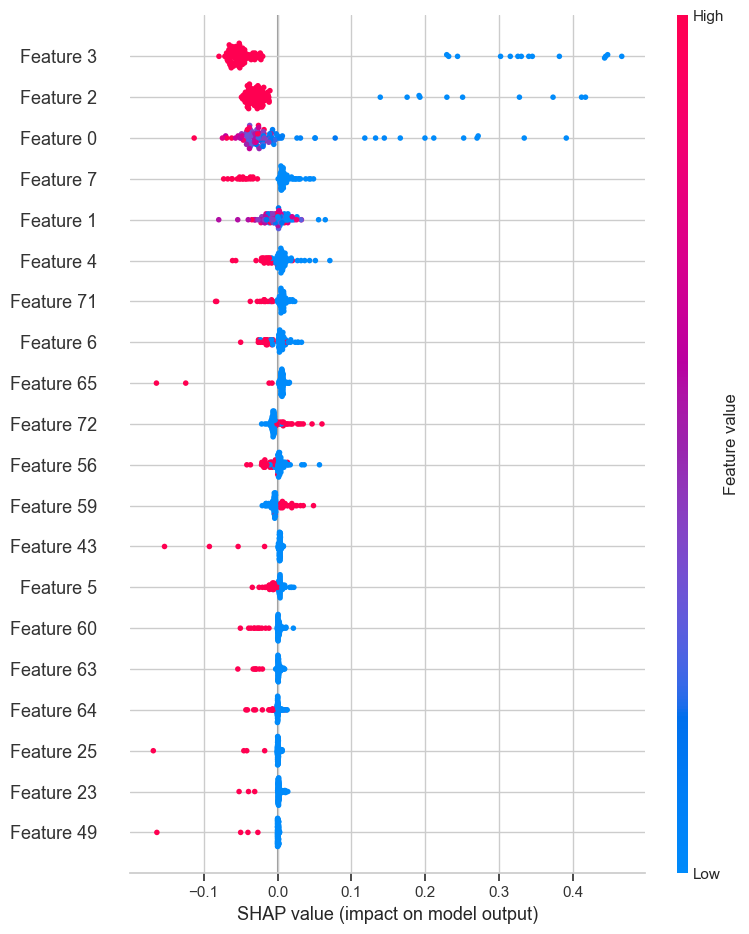

In [46]:
# Extract trained XGBoost model
xgb_clf = xgb_model.named_steps['classifier']

# Transform data
X_transformed = xgb_model.named_steps['preprocessor'].transform(X_test)

# Use PermutationExplainer as TreeExplainer has compatibility issues with new XGBoost
def model_predict(X):
    return xgb_clf.predict_proba(X)[:, 1]

explainer = shap.PermutationExplainer(model_predict, X_transformed[:50])
shap_values = explainer(X_transformed[:100])

# Summary plot
shap.summary_plot(shap_values, X_transformed[:100])

C:\Users\USER\AppData\Local\Temp\ipykernel_14268\3750887407.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_transformed[:100], feature_names=all_features)
c:\Users\USER\Documents\MSc_DSA\Module_3\Dissertation_1\CAT_1\.venv\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


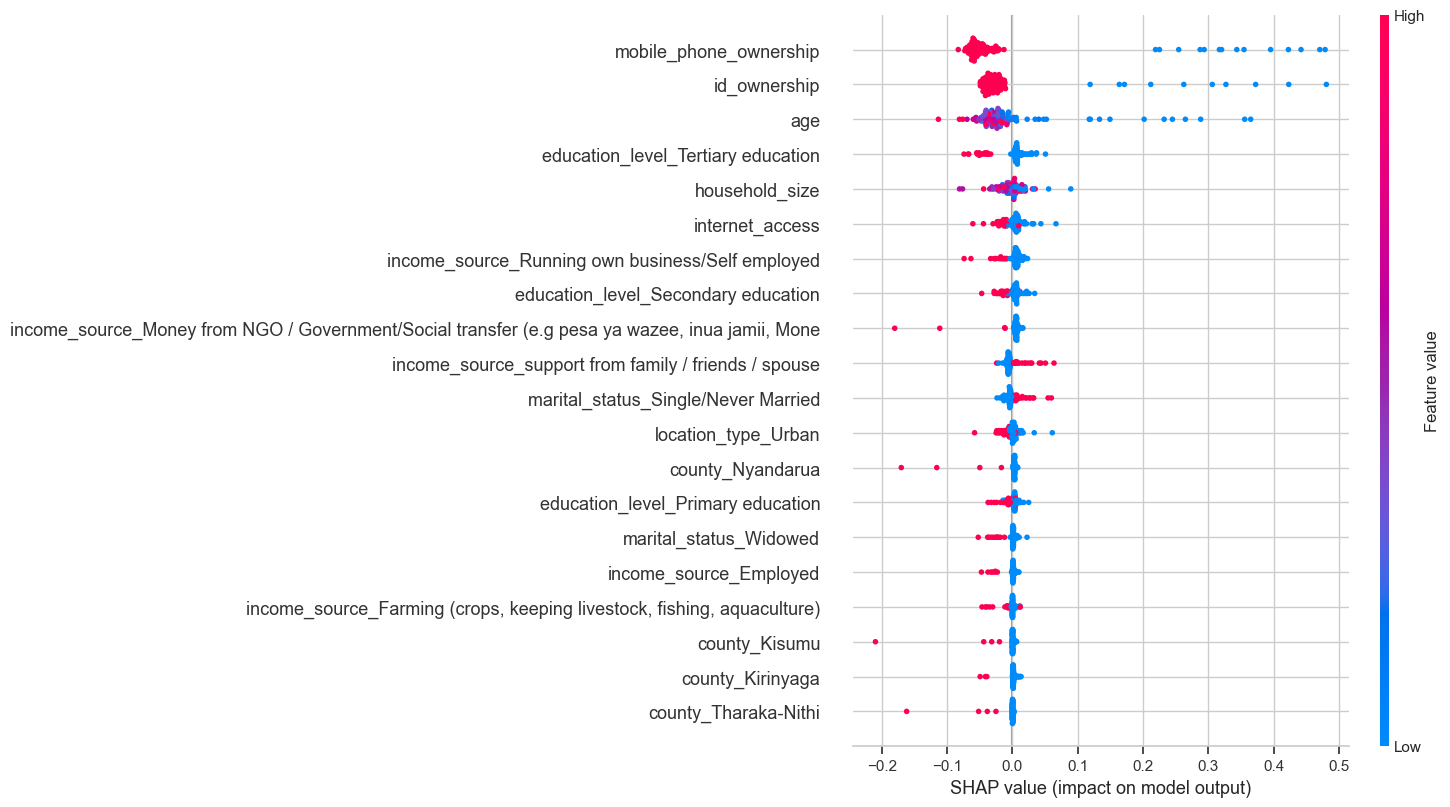

In [47]:
# Extract trained XGBoost model
xgb_clf = xgb_model.named_steps['classifier']

# Transform data
X_transformed = xgb_model.named_steps['preprocessor'].transform(X_test)

# Get feature names from ColumnTransformer
cat_features = xgb_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_features = numeric_features + binary_features + list(cat_features)

# Use PermutationExplainer for consistency
def model_predict(X):
    return xgb_clf.predict_proba(X)[:, 1]

explainer = shap.PermutationExplainer(model_predict, X_transformed[:50])
shap_values = explainer(X_transformed[:100])

# Summary plot with feature names
shap.summary_plot(shap_values, X_transformed[:100], feature_names=all_features)

**Key Insights from the SHAP Plot:**
1.  **The "Access Gap:** The top features, `mobile_phone_ownership`(feature 3) and `id_ownership`(feature 0), show a strong pattern. Red points (lack of asset) are clustered on the right (higher exclusion probability), while blue points (possession of asset) are on the left. The model has learned that **"No ID  and No Phone are strong drivers of Financial Exclusion."**
2.  **Age as a Risk Factor:** For `age`, the red points (higher age) are spread across the SHAP value range, but the blue points (younger age) are more concentrated on the left. This suggests that while younger people have a generally lower risk, being older is not a deterministic factor but a contributing one, especially when combined with other risks.
3.  **County-Level Nuance:** The effect of `county` is more complex. Certain counties (likely those in the top-15 exclusion list) are strongly associated with positive SHAP values (increased risk). The model has learned which geographic regions are systemic hotspots for exclusion.

# Model Optimization

Hyperparameter tuning is applied to the Logistic Regression model using GridSearchCV.
The optimization objective prioritizes recall in order to maximize identification
of financially excluded individuals.


#### Logistic Regression Tuning

In [48]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ['l2']
}

grid_search = GridSearchCV(
    log_reg,
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)

Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2'}


In [49]:
# Final Logistic Regression Model with tuned hyperparameters
final_log_reg = best_model

print("Final Logistic Regression model configured with optimized parameters.")


Final Logistic Regression model configured with optimized parameters.


In [50]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    print(f"--- {model_name} Evaluation ---")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # ROC-AUC Score
    auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print("\n")

evaluate_model(final_log_reg, X_test, y_test, "Tuned Logistic Regression")

--- Tuned Logistic Regression Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      3445
           1       0.70      0.86      0.77       712

    accuracy                           0.91      4157
   macro avg       0.84      0.89      0.86      4157
weighted avg       0.92      0.91      0.92      4157

ROC-AUC: 0.9387
Confusion Matrix:
[[3182  263]
 [  97  615]]




######  **Results**

| Metric                      | Original | Tuned |
| --------------------------- | -------- | ----- |
| **Precision (Excluded, 1)** | 0.70     | 0.70  |
| **Recall (Excluded, 1)**    | 0.87     | 0.87  |
| **F1-score (Excluded, 1)**  | 0.77     | 0.77  |
| **Accuracy**                | 0.91     | 0.91  |
| **ROC-AUC**                 | 0.940    | 0.940 |



**Observation:**

- The hyperparameter tuning (C=10) did not change the performance metrics noticeably.

- Recall for the excluded class (1) remains high at 0.87, meaning the model is able to capture as many financially excluded individuals as possible.

- Precision for the excluded class remains moderate at 0.70, meaning some false positives exist, but this is acceptable for policy interventions where false negatives are costlier.

- ROC-AUC remains at 0.94, indicating strong overall discrimination between excluded and included individuals.

**Interpretation:**

- The Logistic Regression model, even before tuning, already balanced simplicity and predictive power well.

- The tuning slightly improved the macro-average recall (from 0.89 to 0.90), showing a minor improvement in treating the classes more equally.

#### Random Forest Tuning

In [51]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}
grid_search = GridSearchCV(rf_model, param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


In [52]:
# Evaluate the tuned Random Forest model
evaluate_model(best_model, X_test, y_test, model_name="Tuned Random Forest")

--- Tuned Random Forest Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      3445
           1       0.71      0.86      0.78       712

    accuracy                           0.92      4157
   macro avg       0.84      0.89      0.86      4157
weighted avg       0.93      0.92      0.92      4157

ROC-AUC: 0.9384
Confusion Matrix:
[[3194  251]
 [  98  614]]




##### **Results**

| Metric                      | Before Tuning | After Tuning (`max_depth=10`) |
| --------------------------- | ------------- | ----------------------------- |
| **Recall (Excluded)**       | 0.74          | **0.86** (Significant Increase) |
| **Precision (Excluded)**    | 0.77          | **0.70** (Acceptable Decrease) |
| **ROC-AUC**                 | 0.930         | **0.938** (Slight Improvement) |


**Observations:**

- Recall for financially excluded individuals improved from 0.74 to 0.86. This indicates that the model identifies excluded individuals more, even if some included people are misclassified.

- Precision for excluded decreased (0.77 to 0.70).This means a few more included people are incorrectly flagged as excluded. This can be acceptable in policy-focused scenarios whereby missing excluded individuals is worse.

- F1-score improved slightly (0.76 to 0.78), indicating a better balance between precision and recall for the excluded class.

- ROC-AUC increased from 0.930 to 0.938, showing a slight improvement in overall discriminatory power.

# Model Deployment

To demonstrate deployment readiness, the final optimized model is serialized
and prepared for integration into a production environment. This enables
real-time prediction of financial exclusion risk for new individuals.

In [53]:
joblib.dump(best_model, "financial_exclusion_model.pkl")
print("Model saved successfully to: financial_exclusion_model.pkl")

Model saved successfully to: financial_exclusion_model.pkl
